# **U-Net 모델 구현**

✅ 아래 코드는 PyTorch로 작성한 간단한 U-Net 모델입니다.

✅ 주요 목표: 작은 이미지 세트로 segmentation 학습을 테스트하기!

✅ 특징: 업샘플링(deconv/upsample 선택 가능), 입력 스케일링, Gaussian noise 추가, 배치 정규화 적용

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# --- 작은 U-Net 정의 ---
class UNetSmall(nn.Module):
    def __init__(self, upsample_mode='deconv', net_scaling=None, edge_crop=0, gaussian_noise_std=0.1):
        super().__init__()
        self.net_scaling = net_scaling
        self.edge_crop = edge_crop
        self.gaussian_noise_std = gaussian_noise_std
        self.upsample_mode = upsample_mode

         # Convolution Block: Conv -> ReLU -> Conv -> ReLU
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        # 인코더 부분 목표 -> 128 까지!
        self.enc1 = conv_block(3, 8)
        self.enc2 = conv_block(8, 16)
        self.enc3 = conv_block(16, 32)
        self.enc4 = conv_block(32, 64)
        self.center = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2)


        # 업샘플링 부분 정의 (deconv 또는 upsample+conv) 로
        if upsample_mode == 'deconv':
            def upsample_layer(in_c, out_c):
                return nn.ConvTranspose2d(in_c, out_c, 2, stride=2)
        else:
            def upsample_layer(in_c, out_c):
                return nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='nearest'),
                    nn.Conv2d(in_c, out_c, 1)
                )
        # 디코더 부분
        self.up4 = upsample_layer(128, 64)
        self.dec4 = conv_block(128, 64)
        self.up3 = upsample_layer(64, 32)
        self.dec3 = conv_block(64, 32)
        self.up2 = upsample_layer(32, 16)
        self.dec2 = conv_block(32, 16)
        self.up1 = upsample_layer(16, 8)
        self.dec1 = conv_block(16, 8)

        # 최종 출력: 1채널(segmentation mask)
        self.final = nn.Conv2d(8, 1, 1)

    def forward(self, x):
        if self.net_scaling:
        # 입력 스케일링
            x = F.avg_pool2d(x, self.net_scaling)
        # Gaussian noise 추가
        if self.gaussian_noise_std:
            noise = torch.randn_like(x) * self.gaussian_noise_std
            x = x + noise

        # 배치 정규화 적용
        x = F.batch_norm(x, running_mean=None, running_var=None, training=True)

        # 인코더
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        center = self.center(self.pool(e4))
        d4 = self.up4(center)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        out = torch.sigmoid(out)
         # Crop + Pad
        if self.edge_crop > 0:
            out = out[:, :, self.edge_crop:-self.edge_crop, self.edge_crop:-self.edge_crop]
            out = F.pad(out, (self.edge_crop, self.edge_crop, self.edge_crop, self.edge_crop))
        # Upsample 다시 확대
        if self.net_scaling:
            out = F.interpolate(out, scale_factor=self.net_scaling, mode='nearest')

        return out


## **학습용 데이터 생성하기**

In [10]:
batch_size = 32
x = torch.randn(batch_size, 3, 128, 128)  # RGB 이미지
y = (torch.rand(batch_size, 1, 128, 128) > 0.5).float()  # 랜덤 이진 마스크

dataset = TensorDataset(x, y)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

## **데이터 시각화**

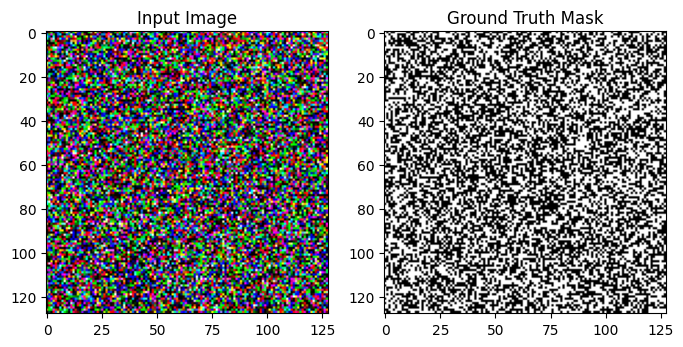

In [11]:
import matplotlib.pyplot as plt
# 첫 번째 이미지를 시각화
sample_x = x[0]
sample_y = y[0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_x.permute(1, 2, 0).numpy())
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.imshow(sample_y.squeeze().numpy(), cmap='gray')
plt.title('Ground Truth Mask')
plt.show()

## **모델 선언 및 학습**

In [12]:
# --- 모델 선언 및 학습 ---
model = UNetSmall(upsample_mode='deconv', net_scaling=None, edge_crop=0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# 간단히 30 epoch만
for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.6968
Epoch 2, Loss: 0.6933
Epoch 3, Loss: 0.6932
Epoch 4, Loss: 0.6931
Epoch 5, Loss: 0.6931
Epoch 6, Loss: 0.6931
Epoch 7, Loss: 0.6931
Epoch 8, Loss: 0.6931
Epoch 9, Loss: 0.6931
Epoch 10, Loss: 0.6931


## **아래 주석을 풀고 U-Net 모델에 대해 간단히 설명해주세요 😀**

[답변]


---
U-Net은 이미지 분할(특히 의료 영상 분할) 작업을 위해 설계된 합성곱 신경망(CNN) 구조이다


인코더와 디코더 구조로 이루어져 있으며, 인코더에서는 특징을 추출하고 디코더에서는 이미지를 복원한다.


특히 인코더의 중간 결과를 디코더로 직접 연결하는 스킵 연결(skip connection)을 통해 세밀한 정보를 유지한다.


## **아래 주석을 풀고 DeepLabv1, v2, v3. v3+  모델에 대해 각각 간단히 설명해주세요 🐶**

[답변]


---

[DeepLab v1]
: Atrous Convolution(공간 확장 합성곱)을 도입해 해상도를 유지하면서 특징을 추출하는 분할 모델이다.

[DeepLab v2]
: Atrous Spatial Pyramid Pooling(ASPP)을 추가해 다양한 크기의 물체를 더 잘 분할할 수 있게 개선했다.

[DeepLab v3]
: ASPP를 강화하고, 더 깊은 레이어를 활용해 복잡한 패턴과 경계도 정밀하게 분할할 수 있게 했다.

[DeepLab v3+]
: DeepLab v3에 디코더 구조를 추가해 경계 복원을 강화하고, 더욱 부드럽고 정확한 분할 결과를 만든다.